In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle as pkl

sns.set_style("darkgrid")

In [2]:
results_df = {"dataset": [], "best_epoch": [], "best_step": [], "best_val_loss": [], "relative_coords": [], "pen_state": [], "stroke_embedding": [], "sketch_pos": [], "stroke_pos": [], "test_acc": [], "seed": []}

for test in [('test', '100-7k'), ('test4', '345-7k')]:
    for filename in os.listdir(f"../checkpoints/{test[0]}/"):
        results_df['dataset'].append(test[1])

        if not os.path.exists(f"../results/{test[0]}/{filename}.pkl"):
            continue

        checkpoint_df = pd.read_csv(f"../checkpoints/{test[0]}/{filename}/lightning_logs/version_0/metrics.csv")
        metrics = checkpoint_df.iloc[checkpoint_df['val_loss'].idxmin()]
        results_df["best_epoch"].append(metrics['epoch'].astype(int))
        results_df["best_step"].append(metrics['step'].astype(int))
        results_df["best_val_loss"].append(metrics['val_loss'])

        with open(f"../results/{test[0]}/{filename}.pkl", "rb") as file:
            results = pkl.load(file)

            for key in results_df.keys() - {"dataset"}:
                if key in ["run", "best_epoch", "best_step", "best_val_loss"]: continue
                results_df[key].append(results["test_results"]['test_acc'] if key == "test_acc" else results["args"][key])

results_df['dataset']
results_df = pd.DataFrame(results_df)
results_df.groupby(["dataset", "relative_coords", "pen_state", "stroke_embedding", "sketch_pos", "stroke_pos"])[['test_acc', 'best_epoch', 'best_step', 'best_val_loss']].agg(['mean', 'sem'])

test_acc  \
                                                                              mean   
dataset relative_coords pen_state stroke_embedding sketch_pos stroke_pos             
100-7k  False           False     True             False      True        0.873323   
                        True      False            True       False       0.874004   
        True            False     True             False      True        0.875643   
                        True      False            True       False       0.882535   
345-7k  False           False     True             False      True        0.807160   
                        True      False            True       False       0.809986   
        True            False     True             False      True        0.807066   
                        True      False            True       False       0.814869   

                                                                                    \
                                                                               sem   
dataset relative_coords pen_state stroke_embedding sketch_pos stroke_pos             
100-7k  False           False     True             False      True        0.000800   
                        True      False            True       False       0.001523   
        True            False     True             False      True        0.000778   
                        True      False            True       False       0.000469   
345-7k  False           False     True             False      True        0.000921   
                        True      False            True       False       0.000333   
        True            False     True             False      True        0.000336   
                        True      False            True       False       0.001472   

                                                                         best_epoch  \
                                                                               mean   
dataset relative_coords pen_state stroke_embedding sketch_pos stroke_pos              
100-7k  False           False     True             False      True        18.666667   
                        True      False            True       False       21.000000   
        True            False     True             False      True        30.000000   
                        True      False            True       False       20.000000   
345-7k  False           False     True             False      True        28.333333   
                        True      False            True       False       30.333333   
        True            False     True             False      True        31.000000   
                        True      False            True       False       28.666667   

                                                                                    \
                                                                               sem   
dataset relative_coords pen_state stroke_embedding sketch_pos stroke_pos             
100-7k  False           False     True             False      True        1.201850   
                        True      False            True       False       0.000000   
        True            False     True             False      True        1.527525   
                        True      False            True       False       0.577350   
345-7k  False           False     True             False      True        1.763834   
                        True      False            True       False       0.666667   
        True            False     True             False      True        0.000000   
                        True      False            True       False       2.333333   

                                                                         best_step  \
                                                                              mean   
dataset relative_coords pen_state stroke_embedding sketch_pos stroke_pos             
100-7k  False    

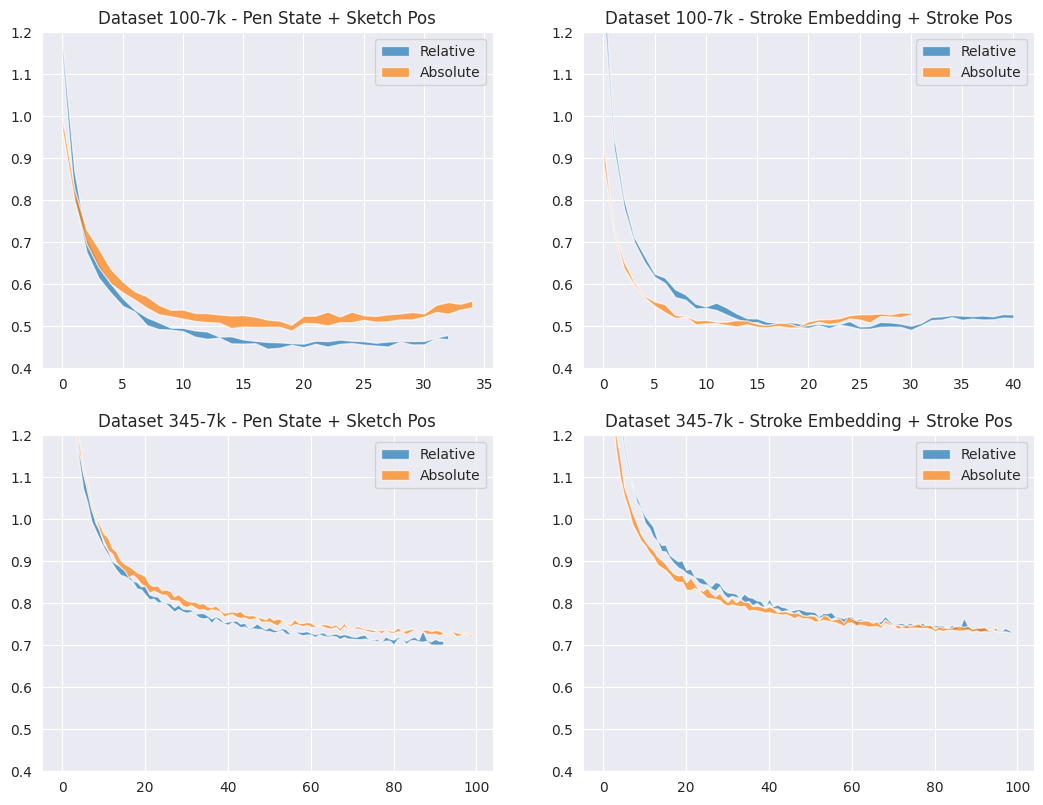

In [4]:
from itertools import product
import numpy as np

fig, axis = plt.subplots(2, 2, figsize=(6.4 * 2, 4.8 * 2))

axis = axis.flatten()

for i, (test, run) in enumerate(product([('test', '100-7k'), ('test4', '345-7k')], [(1, "Pen State + Sketch Pos"), (2, "Stroke Embedding + Stroke Pos")])):
    val_curves1 = []
    val_curves2 = []
    for seed in [42, 1999, 5342]:
        filename = f"run{run[0]}_{seed}"
        metrics1 = pd.read_csv(f"../checkpoints/{test[0]}/{filename}_relative/lightning_logs/version_0/metrics.csv")
        metrics2 = pd.read_csv(f"../checkpoints/{test[0]}/{filename}_absolute/lightning_logs/version_0/metrics.csv")

        val_curves1.append(metrics1[~metrics1['val_loss'].isna()].reset_index()['val_loss'].values)
        val_curves2.append(metrics2[~metrics2['val_loss'].isna()].reset_index()['val_loss'].values)

    min_epochs = min(len(val_curve) for val_curve in val_curves1)
    val_curves_truncated = [val_curve[:min_epochs] for val_curve in val_curves1]

    mean1 = np.mean(val_curves_truncated, axis=0)
    std1 = np.std(val_curves_truncated, axis=0)

    min_epochs = min(len(val_curve) for val_curve in val_curves2)
    val_curves_truncated = [val_curve[:min_epochs] for val_curve in val_curves2]

    mean2 = np.mean(val_curves_truncated, axis=0)
    std2 = np.std(val_curves_truncated, axis=0)

    axis[i].fill_between(range(len(mean1)), mean1 - std1, mean1 + std1, alpha=0.7, label="Relative")
    axis[i].fill_between(range(len(mean2)), mean2 - std2, mean2 + std2, alpha=0.7, label="Absolute")
    axis[i].set_ylim([0.4, 1.2])
    axis[i].set_title(f"Dataset {test[1]} - {run[1]}")
    axis[i].legend()